In [1]:
import platform

print(platform.system())
print(platform.platform())

Linux
Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.35


In [2]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import kagglehub

# 캐글 인증 정보 등록
os.environ["KAGGLE_USERNAME"] = "hahuhah"
os.environ["KAGGLE_KEY"] = "KGAT_f271f8bab359d7b3c1c02d00a4d7030b"

# 다운로드 실행
path = kagglehub.competition_download('ai12-level1-project')
print("축하합니다! 다운로드 완료 경로:", path)

100%|██████████| 1.79G/1.79G [11:20<00:00, 2.83MB/s]

Extracting files...


축하합니다! 다운로드 완료 경로: /home/lee1006hr/.cache/kagglehub/competitions/ai12-level1-project


# Data Engineer 작업 영역

**담당 역할: Data Engineer**  
**산출물**: `data_pipeline.py` (재사용 모듈), `processed/class_mapping.json`, `processed/bbox_stats.json`

이 노트북에서는 다음을 수행합니다.

1. 폴더 구조 탐색 및 자동 경로 탐지
2. per-image COCO json 병합 + bbox 검증(제공 규칙 준수)
3. 클래스 매핑 생성, 클래스 분포 EDA + **비즈니스 가정 검증(이미지당 최대 4개 알약)**
4. Train/Val 분할
5. Albumentations 기반 Dataset/DataLoader 구축
6. 샘플 시각화로 파이프라인 검증
7. `data_pipeline.py` 모듈로 내보내기 (다른 역할이 바로 import 해서 사용)

> 💡 헬스잇(Health Eat) 서비스 시나리오: 사용자는 한 사진에 알약을 **최대 4개**까지 찍습니다.
이 가정이 실제 데이터와 맞는지 EDA 단계에서 직접 검증합니다.

## 1. 폴더 구조 탐색

다운로드한 데이터가 어떤 구조로 정리돼 있는지 먼저 확인합니다.

섹션 1 — 폴더 구조 탐색 (os.walk)
목적: 압축을 풀었을 때 실제 폴더가 어떤 모양인지 눈으로 먼저 확인합니다.

왜 필요한가: 문서에는 train_images, train_annotations라고만 적혀 있지만, 실제 압축 구조는 한 단계 더 중첩돼 있거나(train_images/train_images/) 이름이 살짝 다를 수 있습니다. 이걸 먼저 안 보고 바로 코드를 짜면 FileNotFoundError로 시간을 낭비하게 됩니다.

In [3]:
#따로 다운로드 하지 않고 실행하기 위해
path = "/home/lee1006hr/.cache/kagglehub/competitions/ai12-level1-project"

In [4]:
import os, glob, json as json_lib
from collections import Counter

for root, dirs, files in os.walk(path):
    depth = root.replace(path, "").count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files)[:5]:
        print(f"{indent}  {f}")
    if len(files) > 5:
        print(f"{indent}  ... 총 {len(files)}개 파일")

print()
ext_counter = Counter()
for root, dirs, files in os.walk(path):
    for f in files:
        ext_counter[os.path.splitext(f)[1].lower()] += 1
print("확장자별 개수")
for ext, cnt in ext_counter.most_common():
    print(f"  {ext or '(확장자 없음)'}: {cnt:,}개")

ai12-level1-project/
  sprint_ai_project1_data/
    train_annotations/
    test_images/
      1.png
      10.png
      100.png
      1003.png
      1004.png
      ... 총 842개 파일
    train_images/
      K-001900-016548-019607-029451_0_2_0_2_70_000_200.png
      K-001900-016548-019607-029451_0_2_0_2_75_000_200.png
      K-001900-016548-019607-029451_0_2_0_2_90_000_200.png
      K-001900-016548-019607-033009_0_2_0_2_70_000_200.png
      K-001900-016548-019607-033009_0_2_0_2_75_000_200.png
      ... 총 232개 파일

확장자별 개수
  .png: 1,074개
  .json: 763개


섹션 2 — find_dirs() (경로 자동 탐지)
목적: train_images, train_annotations, test_images 폴더를 키워드로 자동으로 찾아냅니다.

왜 자동 탐지인가: 경로를 하드코딩(path + "/train_images")하면, 폴더 구조가 예상과 1단계만 달라도 코드가 깨집니다. glob으로 탐색하면 중첩 구조든 아니든 견고하게 동작합니다 — 이건 제가 실제 데이터를 열어볼 수 없는 상황에서 일종의 "방어 코드"이기도 합니다.

In [5]:
def find_dirs(data_root):
    def find_one(*keywords):
        for kw in keywords:
            candidates = glob.glob(os.path.join(data_root, "**", f"*{kw}*"), recursive=True)
            dirs = [c for c in candidates if os.path.isdir(c)]
            if dirs:
                return sorted(dirs, key=len)[0]
        return None
    train_img_dir = find_one("train_images", "train_image")
    train_ann_dir = find_one("train_annotations", "train_annotation")
    test_img_dir  = find_one("test_images", "test_image")
    return train_img_dir, train_ann_dir, test_img_dir

train_img_dir, train_ann_dir, test_img_dir = find_dirs(path)
print("train_images      :", train_img_dir)
print("train_annotations :", train_ann_dir)
print("test_images       :", test_img_dir)

train_images      : /home/lee1006hr/.cache/kagglehub/competitions/ai12-level1-project/sprint_ai_project1_data/train_images
train_annotations : /home/lee1006hr/.cache/kagglehub/competitions/ai12-level1-project/sprint_ai_project1_data/train_annotations
test_images       : /home/lee1006hr/.cache/kagglehub/competitions/ai12-level1-project/sprint_ai_project1_data/test_images


섹션 3 — COCO 어노테이션 병합 + 검증
목적: 이미지 1장당 json 파일 1개로 흩어져 있는 어노테이션을 하나의 데이터셋으로 합칩니다.

왜 병합이 필요한가: PyTorch의 Dataset은 "전체 이미지 리스트 + 전체 어노테이션 리스트"가 한 군데 모여 있어야 인덱싱(dataset[idx])이 가능합니다. 파일이 흩어져 있으면 학습 자체가 불가능합니다.

왜 검증이 필요한가: 문서에 명시된 규칙 — "bbox 키가 없거나 비어 있으면 제외", "bbox 길이가 정확히 4여야 함" — 을 어기면 모델 학습 중 unpack 에러가 나거나, 잘못된 박스로 학습이 오염됩니다. 여기서 제외된 어노테이션 수를 출력하는 것도 중요한데, 이 수치가 너무 많으면 데이터 자체에 문제가 있다는 신호이기 때문입니다.

In [6]:
def is_valid_annotation(ann):
    bbox = ann.get("bbox", None)
    if bbox is None or len(bbox) == 0:
        return False
    if not isinstance(bbox, list) or len(bbox) != 4:
        return False
    return True


def merge_coco_annotations(json_paths, verbose=True):
    all_images, all_annotations = [], []
    categories = {}
    n_dropped = 0

    for jp in json_paths:
        try:
            with open(jp, encoding="utf-8") as f:
                data = json_lib.load(f)
        except (json_lib.JSONDecodeError, UnicodeDecodeError):
            continue

        images = data.get("images", [])
        if isinstance(images, dict):
            images = [images]
        all_images.extend(images)

        for ann in data.get("annotations", []):
            if is_valid_annotation(ann):
                all_annotations.append(ann)
            else:
                n_dropped += 1

        for cat in data.get("categories", []):
            categories[cat["id"]] = cat.get("name", str(cat["id"]))

    seen_ids, dedup_images = set(), []
    for img in all_images:
        if img["id"] not in seen_ids:
            dedup_images.append(img)
            seen_ids.add(img["id"])

    if verbose:
        print(f"JSON 파일 {len(json_paths):,}개 병합 완료")
        print(f"  이미지 수        : {len(dedup_images):,}")
        print(f"  유효 어노테이션   : {len(all_annotations):,}")
        print(f"  제외된 어노테이션 : {n_dropped:,}  (bbox 누락/형식 오류)")
        print(f"  클래스 수        : {len(categories):,}")

    return {"images": dedup_images, "annotations": all_annotations, "categories": categories}


json_paths = glob.glob(os.path.join(train_ann_dir, "**", "*.json"), recursive=True)
print(f"발견된 annotation json: {len(json_paths):,}개\n")

merged = merge_coco_annotations(json_paths)

발견된 annotation json: 763개

JSON 파일 763개 병합 완료
  이미지 수        : 232
  유효 어노테이션   : 763
  제외된 어노테이션 : 0  (bbox 누락/형식 오류)
  클래스 수        : 56


섹션 4 — 클래스 매핑
목적: 원본 category_id(예: 199700001 같은 알약 식별자)를 0, 1, 2, ... 같은 연속된 정수로 바꿉니다.

왜 필요한가: 딥러닝 모델의 출력층(Linear(in, num_classes))은 클래스 수만큼의 뉴런을 가져야 하는데, 원본 ID처럼 크고 희소한 숫자를 그대로 쓰면 의미 없이 수억 개의 출력 뉴런이 필요해집니다. 0을 background로 비워두는 것도 torchvision의 detection 모델들이 관습적으로 따르는 규칙입니다.

In [7]:
def build_class_mapping(categories: dict, save_path=None):
    sorted_ids = sorted(categories.keys())
    mapping = {
        "cat_id_to_idx": {cid: i + 1 for i, cid in enumerate(sorted_ids)},
        "idx_to_name":   {i + 1: categories[cid] for i, cid in enumerate(sorted_ids)},
    }
    mapping["idx_to_name"][0] = "background"
    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        with open(save_path, "w", encoding="utf-8") as f:
            json_lib.dump(mapping, f, ensure_ascii=False, indent=2)
    return mapping

os.makedirs("processed", exist_ok=True)
class_mapping = build_class_mapping(merged["categories"], save_path="processed/class_mapping.json")

num_classes = len(class_mapping["idx_to_name"])   # background 포함
print(f"전체 클래스 수 (background 포함): {num_classes}")
print(f"저장 위치: processed/class_mapping.json")

전체 클래스 수 (background 포함): 57
저장 위치: processed/class_mapping.json


섹션 5 — EDA (클래스 분포, bbox 통계, 비즈니스 가정 검증)
목적: 데이터의 특성을 숫자와 그래프로 확인합니다.

왜 필요한가 — 이 섹션은 세 가지 역할을 합니다:

클래스 분포(로그 스케일 그래프) → 특정 알약은 데이터가 매우 적을 수 있다는 걸 미리 알아야, Experimentation Lead가 클래스 불균형 대응(가중 손실 등)을 계획할 수 있습니다.
bbox 크기/종횡비 → Model Architect가 anchor box 크기를 "알약처럼 작은 객체"에 맞게 조정하는 근거 자료입니다. (실제로 model_factory.py의 작은 anchor 설정이 여기서 나왔습니다.)
"최대 4개" 검증 → 헬스잇 프로젝트의 핵심 가정("사용자는 한 사진에 알약을 최대 4개 찍는다")이 실제 데이터와 맞는지 직접 숫자로 확인하는 부분입니다. 이게 틀리면 모델의 detections_per_img=10 설정도 다시 검토해야 합니다.

In [10]:
%pip insatall numpy
%pip install matplotlib


ERROR: unknown command "insatall" - maybe you meant "install"
Note: you may need to restart the kernel to use updated packages.
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 2.1 MB/s  0:00:04 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 2.1 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 1.9 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 1.6 MB/s  0:00:04 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


한글 폰트 설정 완료: NanumGothic


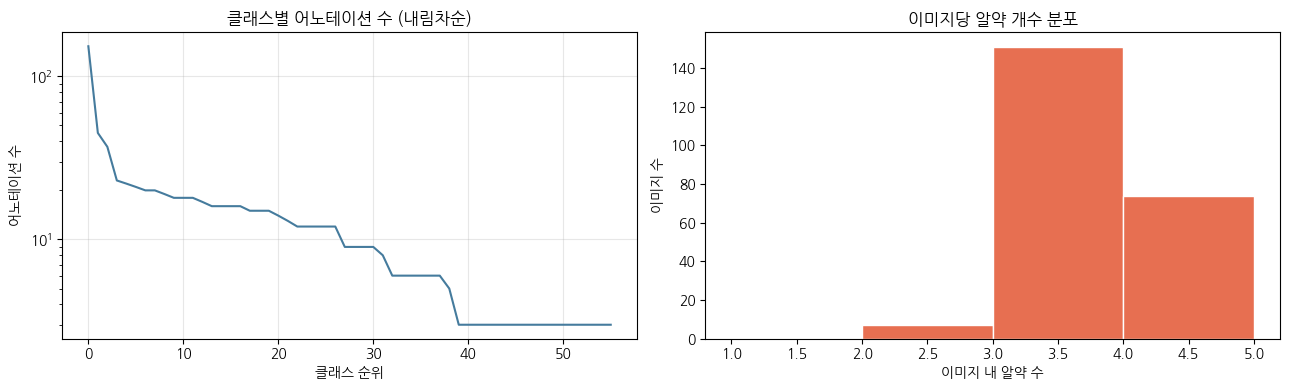

클래스 수: 56
이미지당 평균 알약 수: 3.29
최다 클래스 어노테이션 수: 153 | 최소: 3

이미지당 알약 수 최대값: 4  (4개 초과 이미지: 0장, 0.00%)
✅ '최대 4개' 가정과 일치합니다.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 리눅스 시스템에 설치된 나눔글꼴 경로 설정
# (위의 apt-get으로 설치하면 보통 이 경로에 들어갑니다)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 2. 폰트 이름 가져오기 및 등록
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name

# 3. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 4. Matplotlib 폰트 캐시 초기화 (폰트 설정을 새로고침 합니다)
fm._rebuild() if hasattr(fm, '_rebuild') else os.system('rm -rf ~/.cache/matplotlib')

print(f"한글 폰트 설정 완료: {font_name}")

# ── 클래스별 어노테이션 수 ─────────────────────────────────
class_counter = Counter(ann["category_id"] for ann in merged["annotations"])
counts = sorted(class_counter.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(counts, color="#457b9d")
axes[0].set_title("클래스별 어노테이션 수 (내림차순)")
axes[0].set_xlabel("클래스 순위"); axes[0].set_ylabel("어노테이션 수")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

# ── 이미지당 알약(어노테이션) 개수 분포 ────────────────────
img_ann_counter = Counter(ann["image_id"] for ann in merged["annotations"])
per_image_counts = list(img_ann_counter.values())

axes[1].hist(per_image_counts, bins=range(1, max(per_image_counts)+2), color="#e76f51", edgecolor="white")
axes[1].set_title("이미지당 알약 개수 분포")
axes[1].set_xlabel("이미지 내 알약 수"); axes[1].set_ylabel("이미지 수")

plt.tight_layout(); plt.show()

print(f"클래스 수: {len(class_counter)}")
print(f"이미지당 평균 알약 수: {np.mean(per_image_counts):.2f}")
print(f"최다 클래스 어노테이션 수: {counts[0]:,} | 최소: {counts[-1]:,}")

# ── 비즈니스 가정 검증: "사용자는 한 사진에 알약을 최대 4개까지 찍는다" ──
max_pills = max(per_image_counts)
over_4 = sum(1 for c in per_image_counts if c > 4)
print(f"\n이미지당 알약 수 최대값: {max_pills}  (4개 초과 이미지: {over_4:,}장, "
     f"{over_4/len(per_image_counts)*100:.2f}%)")
if max_pills <= 4:
    print("✅ '최대 4개' 가정과 일치합니다.")
else:
    print("⚠️  일부 이미지가 4개를 초과합니다 — Model Architect에게 전달해 "
         "detections_per_img 여유값(기본 10)이 충분한지 확인이 필요합니다.")

섹션 6 — Train/Val 분할
목적: 전체 이미지를 학습용과 검증용으로 나눕니다.

왜 "이미지 단위"로 나누는가: 만약 어노테이션(알약) 단위로 섞어서 나누면, 같은 사진의 알약 일부는 train에 일부는 val에 들어가는 데이터 누수가 생깁니다. 모델이 이미 본 사진의 일부를 검증에 쓰면 성능이 과대평가됩니다. 그래서 이미지를 통째로 한쪽에만 배정합니다.

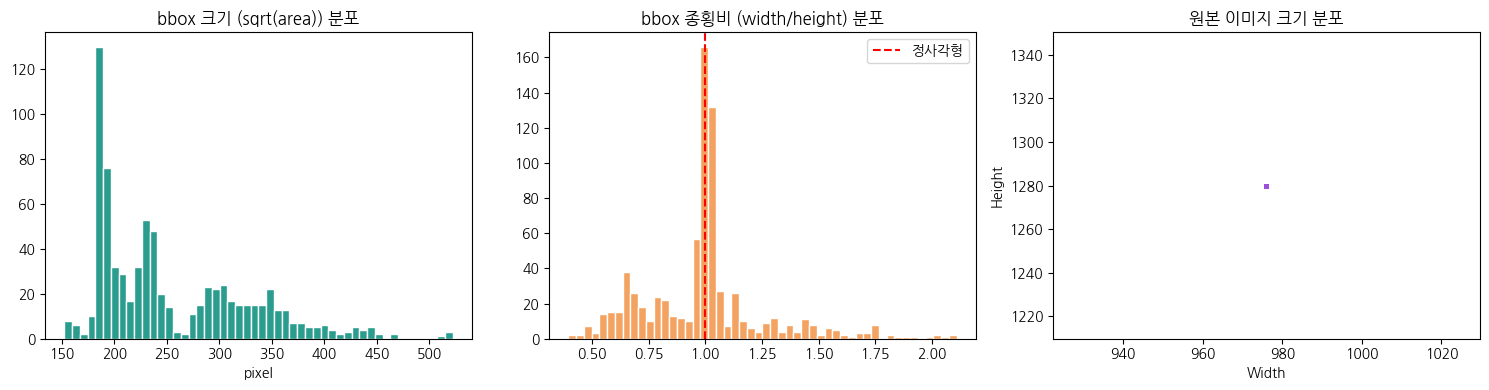

bbox 평균 크기: 250.0 x 265.8 px
bbox 면적 — p10: 34075 | p50: 53600 | p90: 127909


In [9]:
# ── bbox 크기·종횡비 분포 ───────────────────────────────────
widths  = np.array([a["bbox"][2] for a in merged["annotations"]])
heights = np.array([a["bbox"][3] for a in merged["annotations"]])
areas   = widths * heights
aspect  = widths / np.clip(heights, 1e-6, None)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.sqrt(areas), bins=50, color="#2a9d8f", edgecolor="white")
axes[0].set_title("bbox 크기 (sqrt(area)) 분포"); axes[0].set_xlabel("pixel")

axes[1].hist(aspect, bins=50, color="#f4a261", edgecolor="white")
axes[1].set_title("bbox 종횡비 (width/height) 분포")
axes[1].axvline(1.0, color="red", linestyle="--", label="정사각형")
axes[1].legend()

img_sizes = [(img.get("width", 0), img.get("height", 0)) for img in merged["images"]]
ws, hs = zip(*img_sizes) if img_sizes else ([], [])
axes[2].scatter(ws, hs, alpha=0.2, s=5, color="#9d4edd")
axes[2].set_title("원본 이미지 크기 분포")
axes[2].set_xlabel("Width"); axes[2].set_ylabel("Height")

plt.tight_layout(); plt.show()

print(f"bbox 평균 크기: {widths.mean():.1f} x {heights.mean():.1f} px")
print(f"bbox 면적 — p10: {np.percentile(areas,10):.0f} | p50: {np.percentile(areas,50):.0f} | p90: {np.percentile(areas,90):.0f}")

섹션 7 — Dataset / DataLoader (PillDataset)
목적: 위에서 만든 매핑·분할 정보를 가지고 실제로 "이미지 + bbox + 라벨"을 꺼내주는 클래스를 만듭니다.

왜 이렇게 짰는가:

Albumentations 증강(Flip, 회전, 밝기 등): 알약 사진은 촬영 조명·각도가 다양하므로, 증강으로 일반화 성능을 높입니다. 박스 좌표도 같이 변환되도록 bbox_params를 지정한 게 핵심입니다(이미지만 돌리고 박스를 안 돌리면 라벨이 틀려버립니다).
COCO [x,y,w,h] → [x1,y1,x2,y2] 변환: torchvision의 detection 모델(Faster R-CNN 등)은 좌상단/우하단 좌표 형식을 기대하기 때문에 형식을 맞춰줘야 합니다.
_resolve_path의 캐싱+재탐색: 파일명이 폴더 구조와 정확히 안 맞을 가능성에 대비한 안전장치입니다.

In [10]:
# ── bbox 통계 저장 (Model Architect 가 anchor 설계에 참고) ──
def compute_bbox_stats(annotations, save_path=None):
    w = np.array([a["bbox"][2] for a in annotations], dtype=np.float32)
    h = np.array([a["bbox"][3] for a in annotations], dtype=np.float32)
    area = w * h
    stats = {
        "width_mean": float(w.mean()), "width_std": float(w.std()),
        "height_mean": float(h.mean()), "height_std": float(h.std()),
        "area_mean": float(area.mean()),
        "area_p10": float(np.percentile(area, 10)),
        "area_p50": float(np.percentile(area, 50)),
        "area_p90": float(np.percentile(area, 90)),
        "aspect_ratio_mean": float((w / np.clip(h, 1e-6, None)).mean()),
    }
    if save_path:
        with open(save_path, "w", encoding="utf-8") as f:
            json_lib.dump(stats, f, ensure_ascii=False, indent=2)
    return stats

bbox_stats = compute_bbox_stats(merged["annotations"], save_path="processed/bbox_stats.json")
print("bbox_stats.json 저장 완료:")
for k, v in bbox_stats.items():
    print(f"  {k}: {v:.2f}")

bbox_stats.json 저장 완료:
  width_mean: 250.01
  width_std: 73.72
  height_mean: 265.76
  height_std: 95.59
  area_mean: 70384.79
  area_p10: 34075.20
  area_p50: 53600.00
  area_p90: 127908.99
  aspect_ratio_mean: 0.99


섹션 8 — 샘플 시각화
목적: 지금까지 만든 파이프라인이 실제로 제대로 동작하는지 눈으로 직접 확인합니다.

왜 필요한가: 코드가 에러 없이 실행된다고 해서 항상 맞게 동작하는 건 아닙니다(예: 박스가 좌우반전 후 같이 안 돌아갔다든지). 이미지 위에 bbox를 그려서 클래스명까지 같이 보여주면, 버그를 코드 리뷰보다 훨씬 빠르게 잡을 수 있습니다.

In [11]:
import random

def train_val_split(images, val_ratio=0.15, seed=42):
    rng = random.Random(seed)
    shuffled = images.copy()
    rng.shuffle(shuffled)
    n_val = max(1, int(len(shuffled) * val_ratio))
    return shuffled[n_val:], shuffled[:n_val]

train_imgs, val_imgs = train_val_split(merged["images"], val_ratio=0.15, seed=42)
print(f"Train 이미지: {len(train_imgs):,} | Val 이미지: {len(val_imgs):,}")

Train 이미지: 198 | Val 이미지: 34


섹션 9 — data_pipeline.py 모듈로 내보내기
목적: 지금까지 검증한 함수/클래스들을 하나의 .py 파일로 패키징합니다.

왜 필요한가: 이게 이 노트북의 진짜 "산출물"입니다. Model Architect나 Experimentation Lead가 이 노트북 전체를 다시 실행할 필요 없이, from data_pipeline import get_dataloaders 한 줄로 모든 전처리를 재사용할 수 있게 됩니다 — 즉, 역할 간 협업의 인터페이스입니다.

In [12]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 512
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
        A.GaussNoise(p=0.1),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ], bbox_params=A.BboxParams(format="coco", label_fields=["labels"], min_visibility=0.3, clip=True))

def get_val_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ], bbox_params=A.BboxParams(format="coco", label_fields=["labels"], min_visibility=0.3, clip=True))


class PillDataset(Dataset):
    def __init__(self, images, img_to_anns, image_dir, cat_id_to_idx, transform=None):
        self.images = images
        self.img_to_anns = img_to_anns
        self.image_dir = image_dir
        self.cat_id_to_idx = cat_id_to_idx
        self.transform = transform
        self._path_cache = {}

    def __len__(self):
        return len(self.images)

    def _resolve_path(self, file_name):
        if file_name in self._path_cache:
            return self._path_cache[file_name]
        direct = os.path.join(self.image_dir, file_name)
        if os.path.exists(direct):
            resolved = direct
        else:
            matches = glob.glob(os.path.join(self.image_dir, "**", os.path.basename(file_name)), recursive=True)
            resolved = matches[0] if matches else direct
        self._path_cache[file_name] = resolved
        return resolved

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self._resolve_path(img_info["file_name"])
        image = np.array(Image.open(img_path).convert("RGB"))

        anns = self.img_to_anns.get(img_info["id"], [])
        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:
                continue
            boxes.append([float(x), float(y), float(w), float(h)])
            labels.append(self.cat_id_to_idx[ann["category_id"]])

        if self.transform:
            out = self.transform(image=image, bboxes=boxes, labels=labels)
            image, boxes, labels = out["image"], out["bboxes"], out["labels"]
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        boxes_xyxy = [[x, y, x + w, y + h] for x, y, w, h in boxes]
        if len(boxes_xyxy) == 0:
            boxes_t  = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,),  dtype=torch.int64)
        else:
            boxes_t  = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes_t, "labels": labels_t, "image_id": torch.tensor([img_info["id"]])}
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


img_to_anns = {}
for ann in merged["annotations"]:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)

train_set = PillDataset(train_imgs, img_to_anns, train_img_dir, class_mapping["cat_id_to_idx"],
                        transform=get_train_transform())
val_set   = PillDataset(val_imgs,   img_to_anns, train_img_dir, class_mapping["cat_id_to_idx"],
                        transform=get_val_transform())

train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  num_workers=0, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, num_workers=0, collate_fn=collate_fn, pin_memory=True)

print(f"Train: {len(train_set):,}장 ({len(train_loader)} 배치) | Val: {len(val_set):,}장 ({len(val_loader)} 배치)")

Train: 198장 (50 배치) | Val: 34장 (9 배치)


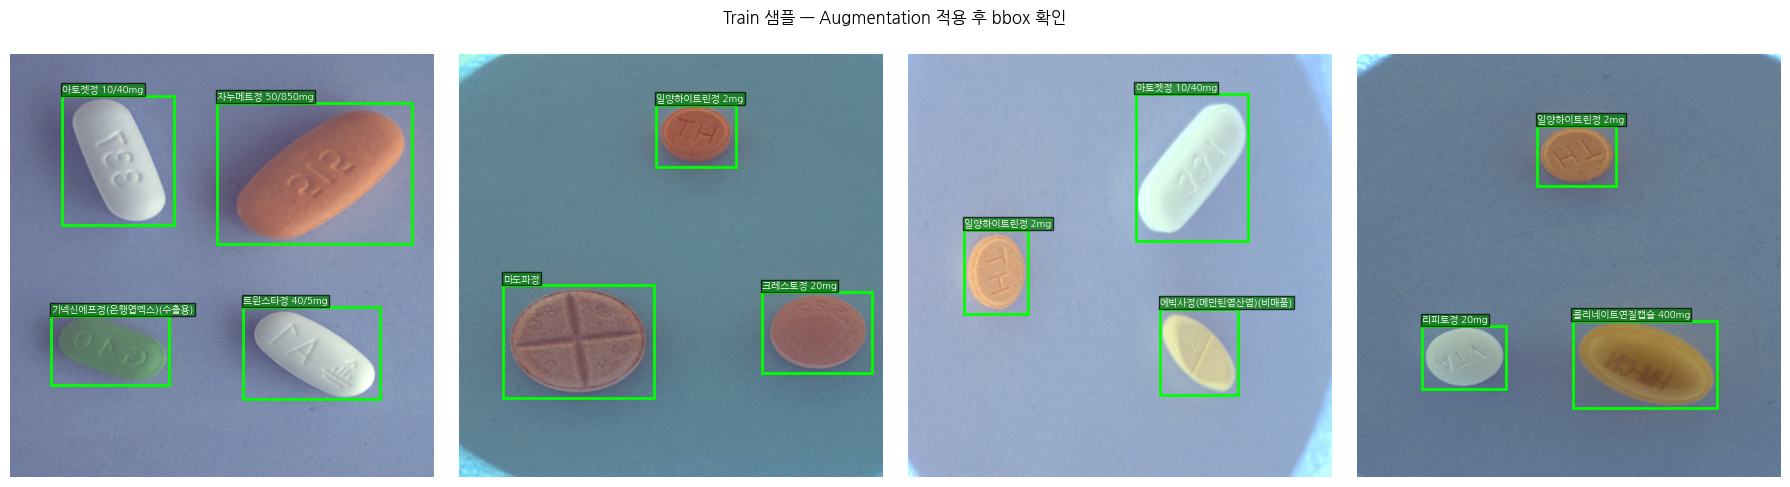

In [13]:
import matplotlib.patches as patches

INV_MEAN = torch.tensor(IMAGENET_MEAN).view(3,1,1)
INV_STD  = torch.tensor(IMAGENET_STD).view(3,1,1)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, idx in zip(axes, random.sample(range(len(train_set)), 4)):
    image, target = train_set[idx]
    img_np = (image * INV_STD + INV_MEAN).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(img_np); ax.axis("off")
    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2,
                                       edgecolor="lime", facecolor="none"))
        name = class_mapping["idx_to_name"].get(label.item(), str(label.item()))
        ax.text(x1, y1-4, name, color="white", fontsize=7,
               bbox=dict(facecolor="green", alpha=0.7, pad=1))
plt.suptitle("Train 샘플 — Augmentation 적용 후 bbox 확인")
plt.tight_layout(); plt.show()

## 10. 핸드오프 노트

✅ **Model Architect / Experimentation Lead 에게 전달**

from data_pipeline import get_dataloaders, load_class_mapping

train_loader, val_loader, class_mapping = get_dataloaders(path, batch_size=4)
num_classes = len(class_mapping["idx_to_name"])   # background 포함

- processed/class_mapping.json : 원본 category_id ↔ 연속 index ↔ 클래스명 매핑
- processed/bbox_stats.json : bbox 크기/종횡비 통계 → Model Architect 의 anchor 설계에 활용
- 데이터 경로가 예상과 다르면 find_dirs(data_root) 결과를 먼저 확인하세요.
- 🎯 비즈니스 가정 검증 결과(이미지당 최대 4개)는 섹션 5에서 확인하세요.

In [14]:
import os
print(os.getcwd())

/mnt/c/Users/leeha/AppData/Local/Programs/Microsoft VS Code


In [15]:
%%writefile /home/lee1006hr/codeit_project1/script/data_pipeline.py
"""
data_pipeline.py
─────────────────────────────────────────────────────────────
Data Engineer 담당 모듈
"""

import os
import glob
import json
import random

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
IMG_SIZE_DEFAULT = 512
PROCESSED_DIR = "processed"
CLASS_MAPPING_FILENAME = "class_mapping.json"
BBOX_STATS_FILENAME = "bbox_stats.json"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def find_dirs(data_root):
    def find_one(*keywords):
        for kw in keywords:
            candidates = glob.glob(os.path.join(data_root, "**", f"*{kw}*"), recursive=True)
            dirs = [c for c in candidates if os.path.isdir(c)]
            if dirs:
                return sorted(dirs, key=len)[0]
        return None

    train_img_dir = find_one("train_images", "train_image")
    train_ann_dir = find_one("train_annotations", "train_annotation")
    test_img_dir = find_one("test_images", "test_image")
    return train_img_dir, train_ann_dir, test_img_dir


def is_valid_annotation(ann):
    bbox = ann.get("bbox", None)
    if bbox is None or len(bbox) == 0:
        return False
    if not isinstance(bbox, list) or len(bbox) != 4:
        return False
    return True


def merge_coco_annotations(json_paths, verbose=True):
    all_images, all_annotations = [], []
    categories = {}
    n_dropped = 0

    for jp in json_paths:
        try:
            with open(jp, encoding="utf-8") as f:
                data = json.load(f)
        except (json.JSONDecodeError, UnicodeDecodeError):
            continue

        images = data.get("images", [])
        if isinstance(images, dict):
            images = [images]
        all_images.extend(images)

        for ann in data.get("annotations", []):
            if is_valid_annotation(ann):
                all_annotations.append(ann)
            else:
                n_dropped += 1

        for cat in data.get("categories", []):
            categories[cat["id"]] = cat.get("name", str(cat["id"]))

    seen_ids = set()
    dedup_images = []
    for img in all_images:
        if img["id"] not in seen_ids:
            dedup_images.append(img)
            seen_ids.add(img["id"])

    if verbose:
        print(f"JSON 파일 {len(json_paths):,}개 병합 완료")
        print(f"  이미지 수        : {len(dedup_images):,}")
        print(f"  유효 어노테이션   : {len(all_annotations):,}")
        print(f"  제외된 어노테이션 : {n_dropped:,}  (bbox 누락/형식 오류)")
        print(f"  클래스 수        : {len(categories):,}")

    return {"images": dedup_images, "annotations": all_annotations, "categories": categories}


def build_class_mapping(categories: dict, save_path=None):
    sorted_ids = sorted(categories.keys())
    mapping = {
        "cat_id_to_idx": {cid: i + 1 for i, cid in enumerate(sorted_ids)},
        "idx_to_name": {i + 1: categories[cid] for i, cid in enumerate(sorted_ids)},
    }
    mapping["idx_to_name"][0] = "background"

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        with open(save_path, "w", encoding="utf-8") as f:
            json.dump(mapping, f, ensure_ascii=False, indent=2)
    return mapping


def load_class_mapping(path):
    with open(path, encoding="utf-8") as f:
        mapping = json.load(f)
    mapping["cat_id_to_idx"] = {int(k): v for k, v in mapping["cat_id_to_idx"].items()}
    mapping["idx_to_name"] = {int(k): v for k, v in mapping["idx_to_name"].items()}
    return mapping


def train_val_split(images, val_ratio=0.15, seed=SEED):
    rng = random.Random(seed)
    shuffled = images.copy()
    rng.shuffle(shuffled)
    n_val = max(1, int(len(shuffled) * val_ratio))
    return shuffled[n_val:], shuffled[:n_val]


def get_train_transform(img_size=IMG_SIZE_DEFAULT):
    return A.Compose(
        [
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
            A.GaussNoise(p=0.1),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ],
        bbox_params=A.BboxParams(format="coco", label_fields=["labels"], min_visibility=0.3, clip=True),
    )


def get_val_transform(img_size=IMG_SIZE_DEFAULT):
    return A.Compose(
        [
            A.Resize(img_size, img_size),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ],
        bbox_params=A.BboxParams(format="coco", label_fields=["labels"], min_visibility=0.3, clip=True),
    )


class PillDataset(Dataset):
    def __init__(self, images, img_to_anns, image_dir, cat_id_to_idx, transform=None):
        self.images = images
        self.img_to_anns = img_to_anns
        self.image_dir = image_dir
        self.cat_id_to_idx = cat_id_to_idx
        self.transform = transform
        self._path_cache = {}

    def __len__(self):
        return len(self.images)

    def _resolve_path(self, file_name):
        if file_name in self._path_cache:
            return self._path_cache[file_name]
        direct = os.path.join(self.image_dir, file_name)
        if os.path.exists(direct):
            resolved = direct
        else:
            matches = glob.glob(os.path.join(self.image_dir, "**", os.path.basename(file_name)), recursive=True)
            resolved = matches[0] if matches else direct
        self._path_cache[file_name] = resolved
        return resolved

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self._resolve_path(img_info["file_name"])
        image = np.array(Image.open(img_path).convert("RGB"))

        anns = self.img_to_anns.get(img_info["id"], [])
        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:
                continue
            boxes.append([float(x), float(y), float(w), float(h)])
            labels.append(self.cat_id_to_idx[ann["category_id"]])

        if self.transform:
            out = self.transform(image=image, bboxes=boxes, labels=labels)
            image = out["image"]
            boxes = out["bboxes"]
            labels = out["labels"]
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        boxes_xyxy = [[x, y, x + w, y + h] for x, y, w, h in boxes]

        if len(boxes_xyxy) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([img_info["id"]]),
        }
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


def compute_bbox_stats(annotations, save_path=None):
    widths = np.array([a["bbox"][2] for a in annotations], dtype=np.float32)
    heights = np.array([a["bbox"][3] for a in annotations], dtype=np.float32)
    areas = widths * heights
    stats = {
        "width_mean": float(widths.mean()), "width_std": float(widths.std()),
        "height_mean": float(heights.mean()), "height_std": float(heights.std()),
        "area_mean": float(areas.mean()),
        "area_p10": float(np.percentile(areas, 10)),
        "area_p50": float(np.percentile(areas, 50)),
        "area_p90": float(np.percentile(areas, 90)),
        "aspect_ratio_mean": float((widths / np.clip(heights, 1e-6, None)).mean()),
    }
    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        with open(save_path, "w", encoding="utf-8") as f:
            json.dump(stats, f, ensure_ascii=False, indent=2)
    return stats


def get_dataloaders(
    data_root,
    batch_size=4,
    img_size=IMG_SIZE_DEFAULT,
    val_ratio=0.15,
    seed=SEED,
    num_workers=0,
    processed_dir=PROCESSED_DIR,
):
    train_img_dir, train_ann_dir, _ = find_dirs(data_root)
    if train_img_dir is None or train_ann_dir is None:
        raise FileNotFoundError(
            "train_images / train_annotations 폴더를 찾지 못했습니다. "
            "data_root 경로를 확인하거나 find_dirs() 결과를 직접 지정해 주세요."
        )

    json_paths = glob.glob(os.path.join(train_ann_dir, "**", "*.json"), recursive=True)
    merged = merge_coco_annotations(json_paths)

    os.makedirs(processed_dir, exist_ok=True)
    mapping = build_class_mapping(
        merged["categories"], save_path=os.path.join(processed_dir, CLASS_MAPPING_FILENAME)
    )
    compute_bbox_stats(merged["annotations"], save_path=os.path.join(processed_dir, BBOX_STATS_FILENAME))

    img_to_anns = {}
    for ann in merged["annotations"]:
        img_to_anns.setdefault(ann["image_id"], []).append(ann)

    train_imgs, val_imgs = train_val_split(merged["images"], val_ratio=val_ratio, seed=seed)

    train_set = PillDataset(
        train_imgs, img_to_anns, train_img_dir, mapping["cat_id_to_idx"],
        transform=get_train_transform(img_size),
    )
    val_set = PillDataset(
        val_imgs, img_to_anns, train_img_dir, mapping["cat_id_to_idx"],
        transform=get_val_transform(img_size),
    )

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, collate_fn=collate_fn, pin_memory=True,
    )
    val_loader = DataLoader(
        val_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, collate_fn=collate_fn, pin_memory=True,
    )

    return train_loader, val_loader, mapping

Writing /home/lee1006hr/codeit_project1/script/data_pipeline.py
